In [1]:
# packages
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [4]:
sst_train_input_reconstructed = np.load("sst_train_input_reconstructed.npy")
sst_train_output_reconstructed = np.load("sst_train_output_reconstructed.npy")
ohc_train_input_reconstructed = np.load("ohc_train_input_reconstructed.npy")
ohc_train_output_reconstructed = np.load("ohc_train_output_reconstructed.npy")
olr_train_input_reconstructed = np.load("olr_train_input_reconstructed.npy")
olr_train_output_reconstructed = np.load("olr_train_output_reconstructed.npy")

In [5]:
sst_test_input_reconstructed = np.load("sst_test_input_reconstructed.npy")
sst_test_output_reconstructed = np.load("sst_test_output_reconstructed.npy")
ohc_test_input_reconstructed = np.load("ohc_test_input_reconstructed.npy")
ohc_test_output_reconstructed = np.load("ohc_test_output_reconstructed.npy")
olr_test_input_reconstructed = np.load("olr_test_input_reconstructed.npy")
olr_test_output_reconstructed = np.load("olr_test_output_reconstructed.npy")

In [6]:
print(sst_train_input_reconstructed.shape,
      sst_train_output_reconstructed.shape,
      ohc_train_input_reconstructed.shape,
      ohc_train_output_reconstructed.shape,
      olr_train_input_reconstructed.shape,
      olr_train_output_reconstructed.shape
     )

print(sst_test_input_reconstructed.shape,
      sst_test_output_reconstructed.shape,
      ohc_test_input_reconstructed.shape,
      ohc_test_output_reconstructed.shape,
      olr_test_input_reconstructed.shape,
      olr_test_output_reconstructed.shape
     )

(4800, 20, 150) (4800, 20, 150) (4800, 20, 150) (4800, 20, 150) (4800, 22, 121) (4800, 22, 121)
(1200, 20, 150) (1200, 20, 150) (1200, 20, 150) (1200, 20, 150) (1200, 22, 121) (1200, 22, 121)


## metrics without bootstrapping, per sample, spatially aggregated

In [7]:
# nan safe
def per_sample_metrics(y_true, y_pred, min_valid_frac=0.1):
    """
    Compute RMSE, MAE, R^2 per sample, ignoring NaNs.
    
    Parameters
    ----------
    min_valid_frac : float
        Minimum fraction of valid pixels required to compute metrics
    
    Returns
    -------
    rmse, mae, r2 : (N,) arrays (NaN if insufficient data)
    """
    if y_true.shape != y_pred.shape:
        raise ValueError("Shapes must match")

    N = y_true.shape[0]
    y_true_f = y_true.reshape(N, -1)
    y_pred_f = y_pred.reshape(N, -1)

    rmse = np.full(N, np.nan)
    mae  = np.full(N, np.nan)
    r2   = np.full(N, np.nan)

    for i in range(N):
        valid = np.isfinite(y_true_f[i]) & np.isfinite(y_pred_f[i])
        if valid.sum() < min_valid_frac * valid.size:
            continue

        yt = y_true_f[i, valid]
        yp = y_pred_f[i, valid]
        diff = yp - yt

        rmse[i] = np.sqrt(np.mean(np.square(diff)))
        mae[i]  = np.mean(np.abs(diff))

        sst = np.sum(np.square(yt - yt.mean()))
        if sst > 0:
            sse = np.sum(np.square(diff))
            r2[i] = 1.0 - sse / sst

    return rmse, mae, r2

In [8]:
# training
sst_train_rmse, sst_train_mae, sst_train_r2 = per_sample_metrics(
    sst_train_input_reconstructed,
    sst_train_output_reconstructed
)

ohc_train_rmse, ohc_train_mae, ohc_train_r2 = per_sample_metrics(
    ohc_train_input_reconstructed,
    ohc_train_output_reconstructed
)

olr_train_rmse, olr_train_mae, olr_train_r2 = per_sample_metrics(
    olr_train_input_reconstructed,
    olr_train_output_reconstructed
)

In [9]:
print(sst_train_rmse.shape)

(4800,)


In [10]:
# SST
sst_train_mean_rmse = np.nanmean(sst_train_rmse)
sst_train_std_rmse  = np.nanstd(sst_train_rmse)
sst_train_mean_mae  = np.nanmean(sst_train_mae)
sst_train_std_mae   = np.nanstd(sst_train_mae)
sst_train_mean_r2   = np.nanmean(sst_train_r2)
sst_train_std_r2    = np.nanstd(sst_train_r2)

print(f"SST RMSE Train Mean: {sst_train_mean_rmse:.6f}, Train STD: {sst_train_std_rmse:.6f}")
print(f"SST MAE  Train Mean: {sst_train_mean_mae:.6f}, Train STD: {sst_train_std_mae:.6f}")
print(f"SST R2   Train Mean: {sst_train_mean_r2:.6f}, Train STD: {sst_train_std_r2:.6f}")

# OHC
ohc_train_mean_rmse = np.nanmean(ohc_train_rmse)
ohc_train_std_rmse  = np.nanstd(ohc_train_rmse)
ohc_train_mean_mae  = np.nanmean(ohc_train_mae)
ohc_train_std_mae   = np.nanstd(ohc_train_mae)
ohc_train_mean_r2   = np.nanmean(ohc_train_r2)
ohc_train_std_r2    = np.nanstd(ohc_train_r2)

print('')
print(f"OHC RMSE Train Mean: {ohc_train_mean_rmse:.6f}, Train STD: {ohc_train_std_rmse:.6f}")
print(f"OHC MAE  Train Mean: {ohc_train_mean_mae:.6f}, Train STD: {ohc_train_std_mae:.6f}")
print(f"OHC R2   Train Mean: {ohc_train_mean_r2:.6f}, Train STD: {ohc_train_std_r2:.6f}")

# OLR
olr_train_mean_rmse = np.nanmean(olr_train_rmse)
olr_train_std_rmse  = np.nanstd(olr_train_rmse)
olr_train_mean_mae  = np.nanmean(olr_train_mae)
olr_train_std_mae   = np.nanstd(olr_train_mae)
olr_train_mean_r2   = np.nanmean(olr_train_r2)
olr_train_std_r2    = np.nanstd(olr_train_r2)

print('')
print(f"OLR RMSE Train Mean: {olr_train_mean_rmse:.6f}, Train STD: {olr_train_std_rmse:.6f}")
print(f"OLR MAE  Train Mean: {olr_train_mean_mae:.6f}, Train STD: {olr_train_std_mae:.6f}")
print(f"OLR R2   Train Mean: {olr_train_mean_r2:.6f}, Train STD: {olr_train_std_r2:.6f}")

SST RMSE Train Mean: 0.272918, Train STD: 0.043466
SST MAE  Train Mean: 0.211126, Train STD: 0.033185
SST R2   Train Mean: 0.652977, Train STD: 0.216022

OHC RMSE Train Mean: 320140135.762946, Train STD: 52854011.325351
OHC MAE  Train Mean: 245524304.924084, Train STD: 41701377.533975
OHC R2   Train Mean: 0.713484, Train STD: 0.183267

OLR RMSE Train Mean: 8.133120, Train STD: 1.654232
OLR MAE  Train Mean: 6.003176, Train STD: 1.387885
OLR R2   Train Mean: 0.612025, Train STD: 0.163433


In [11]:
# testing
sst_test_rmse, sst_test_mae, sst_test_r2 = per_sample_metrics(
    sst_test_input_reconstructed,
    sst_test_output_reconstructed
)

ohc_test_rmse, ohc_test_mae, ohc_test_r2 = per_sample_metrics(
    ohc_test_input_reconstructed,
    ohc_test_output_reconstructed
)

olr_test_rmse, olr_test_mae, olr_test_r2 = per_sample_metrics(
    olr_test_input_reconstructed,
    olr_test_output_reconstructed
)

In [12]:
sst_test_rmse.shape

(1200,)

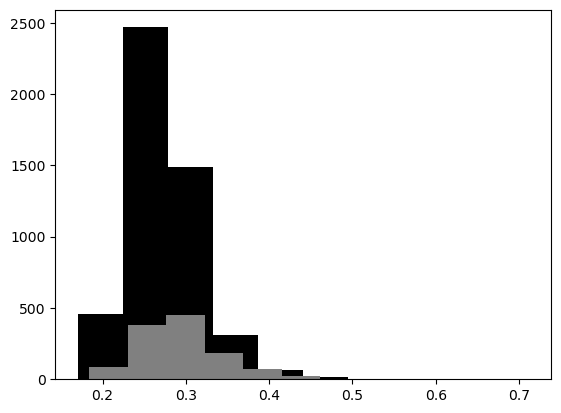

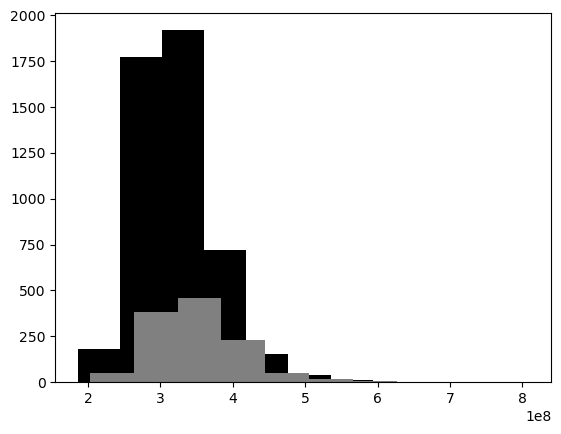

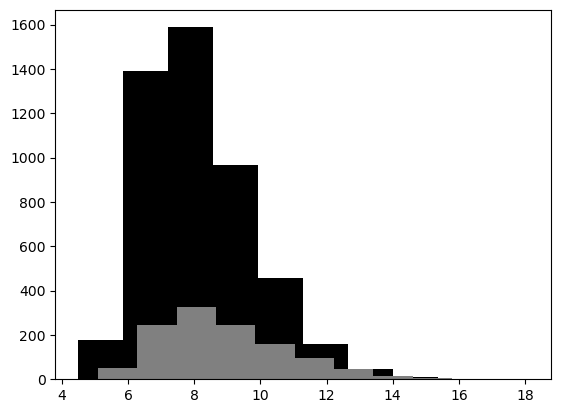

In [13]:
# lots of overlap in distributions of error between train and test -- nice!
plt.hist(sst_train_rmse, color='k'); plt.hist(sst_test_rmse, color='grey'); plt.show()
plt.hist(ohc_train_rmse, color='k'); plt.hist(ohc_test_rmse, color='grey'); plt.show()
plt.hist(olr_train_rmse, color='k'); plt.hist(olr_test_rmse, color='grey'); plt.show()

In [14]:
# SST
sst_test_mean_rmse = np.nanmean(sst_test_rmse)
sst_test_std_rmse  = np.nanstd(sst_test_rmse)
sst_test_mean_mae  = np.nanmean(sst_test_mae)
sst_test_std_mae   = np.nanstd(sst_test_mae)
sst_test_mean_r2   = np.nanmean(sst_test_r2)
sst_test_std_r2    = np.nanstd(sst_test_r2)

print(f"SST RMSE Test Mean: {sst_test_mean_rmse:.6f}, Test STD: {sst_test_std_rmse:.6f}")
print(f"SST MAE  Test Mean: {sst_test_mean_mae:.6f}, Test STD: {sst_test_std_mae:.6f}")
print(f"SST R2   Test Mean: {sst_test_mean_r2:.6f}, Test STD: {sst_test_std_r2:.6f}")

# OHC
ohc_test_mean_rmse = np.nanmean(ohc_test_rmse)
ohc_test_std_rmse  = np.nanstd(ohc_test_rmse)
ohc_test_mean_mae  = np.nanmean(ohc_test_mae)
ohc_test_std_mae   = np.nanstd(ohc_test_mae)
ohc_test_mean_r2   = np.nanmean(ohc_test_r2)
ohc_test_std_r2    = np.nanstd(ohc_test_r2)

print('')
print(f"OHC RMSE Test Mean: {ohc_test_mean_rmse:.6f}, Test STD: {ohc_test_std_rmse:.6f}")
print(f"OHC MAE  Test Mean: {ohc_test_mean_mae:.6f}, Test STD: {ohc_test_std_mae:.6f}")
print(f"OHC R2   Test Mean: {ohc_test_mean_r2:.6f}, Test STD: {ohc_test_std_r2:.6f}")

# OLR
olr_test_mean_rmse = np.nanmean(olr_test_rmse)
olr_test_std_rmse  = np.nanstd(olr_test_rmse)
olr_test_mean_mae  = np.nanmean(olr_test_mae)
olr_test_std_mae   = np.nanstd(olr_test_mae)
olr_test_mean_r2   = np.nanmean(olr_test_r2)
olr_test_std_r2    = np.nanstd(olr_test_r2)

print('')
print(f"OLR RMSE Test Mean: {olr_test_mean_rmse:.6f}, Test STD: {olr_test_std_rmse:.6f}")
print(f"OLR MAE  Test Mean: {olr_test_mean_mae:.6f}, Test STD: {olr_test_std_mae:.6f}")
print(f"OLR R2   Test Mean: {olr_test_mean_r2:.6f}, Test STD: {olr_test_std_r2:.6f}")

SST RMSE Test Mean: 0.295646, Test STD: 0.051990
SST MAE  Test Mean: 0.229457, Test STD: 0.040648
SST R2   Test Mean: 0.594462, Test STD: 0.260037

OHC RMSE Test Mean: 350384436.601058, Test STD: 62489773.183532
OHC MAE  Test Mean: 270494743.978541, Test STD: 49726171.233886
OHC R2   Test Mean: 0.660773, Test STD: 0.220864

OLR RMSE Test Mean: 8.896139, Test STD: 1.865763
OLR MAE  Test Mean: 6.604260, Test STD: 1.572576
OLR R2   Test Mean: 0.538989, Test STD: 0.199080


## skill ratio

In [15]:
# sst
sr_sst_rmse = sst_test_mean_rmse / sst_train_mean_rmse
sr_sst_mae = sst_test_mean_mae / sst_train_mean_mae
sr_sst_r2 = sst_test_mean_r2 / sst_train_mean_r2

print(f"SST RMSE SR: {sr_sst_rmse:.4f}")
print(f"SST MAE  SR: {sr_sst_mae:.6f}")
print(f"SST R2   SR: {sr_sst_r2:.6f}")

SST RMSE SR: 1.0833
SST MAE  SR: 1.086826
SST R2   SR: 0.910387


In [16]:
# ohc
sr_ohc_rmse = ohc_test_mean_rmse / ohc_train_mean_rmse
sr_ohc_mae = ohc_test_mean_mae / ohc_train_mean_mae
sr_ohc_r2 = ohc_test_mean_r2 / ohc_train_mean_r2

print(f"OHC RMSE SR: {sr_ohc_rmse:.4f}")
print(f"OHC MAE  SR: {sr_ohc_mae:.6f}")
print(f"OHC R2   SR: {sr_ohc_r2:.6f}")

OHC RMSE SR: 1.0945
OHC MAE  SR: 1.101703
OHC R2   SR: 0.926122


In [17]:
# ohc
sr_olr_rmse = olr_test_mean_rmse / olr_train_mean_rmse
sr_olr_mae = olr_test_mean_mae / olr_train_mean_mae
sr_olr_r2 = olr_test_mean_r2 / olr_train_mean_r2

print(f"OLR RMSE SR: {sr_olr_rmse:.4f}")
print(f"OLR MAE  SR: {sr_olr_mae:.6f}")
print(f"OLR R2   SR: {sr_olr_r2:.6f}")

OLR RMSE SR: 1.0938
OLR MAE  SR: 1.100128
OLR R2   SR: 0.880665


## testing metrics with bootstrapping

In [16]:
# assumptions:
## test set size: 1200 samples
## bootstrap sample size per iteration: 1200 samples
## bootstrap iterations: 1000
## metrics are already computed above per sample over space
## sampling is with replacement
## we will not recompute spatial errors inside the bootstrap loop
## we will recompute per sample metrics after resampling

In [17]:
def _make_bootstrap_indices(rng, N, sample_size, method="iid", block_size=None, circular=False):
    """
    Create bootstrap indices for a time axis of length N.

    method:
      - "iid": sample indices with replacement
      - "block": moving-block bootstrap (sample contiguous blocks with replacement)

    circular:
      - If True, blocks can wrap around the end (circular blocks)
      - If False, block starts are limited so blocks stay within [0, N)
    """
    if sample_size is None:
        sample_size = N

    if method == "iid":
        return rng.choice(N, size=sample_size, replace=True)

    if method != "block":
        raise ValueError(f"Unknown method: {method}. Use 'iid' or 'block'.")

    if block_size is None or block_size <= 0:
        raise ValueError("block_size must be a positive integer when method='block'.")
    if block_size > N and not circular:
        raise ValueError("block_size cannot exceed N when circular=False.")

    n_blocks = int(np.ceil(sample_size / block_size))

    if circular:
        starts = rng.integers(0, N, size=n_blocks)
        idx = []
        for s in starts:
            idx.extend([(s + k) % N for k in range(block_size)])
        return np.array(idx[:sample_size], dtype=int)
    else:
        max_start = N - block_size
        starts = rng.integers(0, max_start + 1, size=n_blocks)
        idx = []
        for s in starts:
            idx.extend(range(s, s + block_size))
        return np.array(idx[:sample_size], dtype=int)

def global_metrics_nan_safe(y_true, y_pred, min_valid_frac=0.1):
    """
    Compute global (pooled) RMSE, MAE, R^2 across ALL selected samples and elements,
    ignoring NaNs/Infs in either array.

    Returns NaN for a metric if insufficient valid data or undefined (e.g., R^2 with zero SST).
    """
    if y_true.shape != y_pred.shape:
        raise ValueError("Shapes must match")

    N = y_true.shape[0]
    yt = y_true.reshape(N, -1)
    yp = y_pred.reshape(N, -1)

    valid = np.isfinite(yt) & np.isfinite(yp)
    valid_frac = valid.mean()
    if valid_frac < min_valid_frac:
        return np.nan, np.nan, np.nan

    yt_v = yt[valid]
    yp_v = yp[valid]
    diff = yp_v - yt_v

    rmse = np.sqrt(np.mean(np.square(diff)))
    mae  = np.mean(np.abs(diff))

    ybar = np.mean(yt_v)
    sst = np.sum(np.square(yt_v - ybar))
    if sst > 0:
        sse = np.sum(np.square(diff))
        r2 = 1.0 - sse / sst
    else:
        r2 = np.nan

    return rmse, mae, r2

def bootstrap_mean_metrics(
    y_true,
    y_pred,
    n_boot=1000,
    sample_size=None,
    random_seed=42,
    min_valid_frac=0.1,
    resample_method="iid",      # "iid" or "block"
    block_size=None,            # required if resample_method="block"
    circular_blocks=False,      # only used for block bootstrap
    r2_mode="mean",             # "mean" (per-sample mean R^2) or "global" (pooled R^2)
):
    """
    Bootstrap mean RMSE, MAE, and R^2 over resampled time steps.

    Parameters
    ----------
    resample_method : {"iid", "block"}
        "iid" resamples time indices independently with replacement.
        "block" uses a moving-block bootstrap (contiguous blocks) to better respect temporal dependence.
    block_size : int
        Length of each block for block bootstrap.
    circular_blocks : bool
        If True, blocks can wrap around the end (circular bootstrap).
    r2_mode : {"mean", "global"}
        - "mean": compute per-sample metrics and take nanmean across samples (your current approach).
        - "global": compute pooled (global) metrics across all valid elements of the resample.
          In this mode, RMSE/MAE also become global pooled metrics (recommended for consistency).

    Returns
    -------
    rmse_boot, mae_boot, r2_boot : (n_boot,) arrays
    """
    if y_true.shape != y_pred.shape:
        raise ValueError("Shapes must match")

    rng = np.random.default_rng(random_seed)
    N = y_true.shape[0]
    if sample_size is None:
        sample_size = N

    rmse_boot = np.full(n_boot, np.nan)
    mae_boot  = np.full(n_boot, np.nan)
    r2_boot   = np.full(n_boot, np.nan)

    for b in range(n_boot):
        idx = _make_bootstrap_indices(
            rng, N, sample_size,
            method=resample_method,
            block_size=block_size,
            circular=circular_blocks
        )

        yt_b = y_true[idx]
        yp_b = y_pred[idx]

        if r2_mode == "global":
            rmse_boot[b], mae_boot[b], r2_boot[b] = global_metrics_nan_safe(
                yt_b, yp_b, min_valid_frac=min_valid_frac
            )
        elif r2_mode == "mean":
            rmse_s, mae_s, r2_s = per_sample_metrics(
                yt_b, yp_b, min_valid_frac=min_valid_frac
            )
            rmse_boot[b] = np.nanmean(rmse_s)
            mae_boot[b]  = np.nanmean(mae_s)
            r2_boot[b]   = np.nanmean(r2_s)
        else:
            raise ValueError("r2_mode must be 'mean' or 'global'")

    return rmse_boot, mae_boot, r2_boot

def bootstrap_ci(x, ci=(2.5, 97.5)):
    return np.nanpercentile(x, ci, axis=0)

In [18]:
## compute confidence interval on delta (test metric - train metrics)
## ci includes zero --> cannot distinguish between testing and training
## ci entirely above zero --> test is significantly worse
## ci entirely below zero (likely not going to happen) --> test is significantly better

In [19]:
def bootstrap_metric_difference(
    y_true_test,
    y_pred_test,
    y_true_train,
    y_pred_train,
    metric="mae",               # "mae", "rmse", or "r2"
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    min_valid_frac=0.1,
    resample_method="iid",
    block_size=None,
    circular_blocks=False,
    r2_mode="mean",             # "mean" (default) or "global"
):
    """
    Bootstrap the difference: (test metric - train metric).

    Important:
    Supports r2_mode = "mean" or "global" to match existing metric logic.

    Returns
    -------
    diff_boot : (n_boot,) array
        Bootstrap distribution of differences.
    """

    if y_true_test.shape != y_pred_test.shape:
        raise ValueError("Test shapes must match")
    if y_true_train.shape != y_pred_train.shape:
        raise ValueError("Train shapes must match")

    rng_train = np.random.default_rng(random_seed)
    rng_test = np.random.default_rng(random_seed + 1)

    N_test  = y_true_test.shape[0]
    N_train = y_true_train.shape[0]

    diff_boot = np.full(n_boot, np.nan)

    for b in range(n_boot):

        # --- independent resampling ---
        idx_test = _make_bootstrap_indices(
            rng_test, N_test, test_sample_size,
            method=resample_method,
            block_size=block_size,
            circular=circular_blocks,
        )

        idx_train = _make_bootstrap_indices(
            rng_train, N_train, train_sample_size,
            method=resample_method,
            block_size=block_size,
            circular=circular_blocks,
        )

        yt_test  = y_true_test[idx_test]
        yp_test  = y_pred_test[idx_test]
        yt_train = y_true_train[idx_train]
        yp_train = y_pred_train[idx_train]

        # --- compute metrics using the SAME logic as elsewhere ---
        if r2_mode == "global":
            rmse_t, mae_t, r2_t = global_metrics_nan_safe(
                yt_test, yp_test, min_valid_frac=min_valid_frac
            )
            rmse_r, mae_r, r2_r = global_metrics_nan_safe(
                yt_train, yp_train, min_valid_frac=min_valid_frac
            )

        elif r2_mode == "mean":
            rmse_s_t, mae_s_t, r2_s_t = per_sample_metrics(
                yt_test, yp_test, min_valid_frac=min_valid_frac
            )
            rmse_s_r, mae_s_r, r2_s_r = per_sample_metrics(
                yt_train, yp_train, min_valid_frac=min_valid_frac
            )

            rmse_t = np.nanmean(rmse_s_t)
            mae_t  = np.nanmean(mae_s_t)
            r2_t   = np.nanmean(r2_s_t)

            rmse_r = np.nanmean(rmse_s_r)
            mae_r  = np.nanmean(mae_s_r)
            r2_r   = np.nanmean(r2_s_r)

        else:
            raise ValueError("r2_mode must be 'mean' or 'global'")

        # --- store requested difference ---
        if metric == "mae":
            diff_boot[b] = mae_t - mae_r
        elif metric == "rmse":
            diff_boot[b] = rmse_t - rmse_r
        elif metric == "r2":
            diff_boot[b] = r2_t - r2_r
        else:
            raise ValueError("metric must be 'mae', 'rmse', or 'r2'")

    return diff_boot

In [20]:
sst_test_rmse_boot, sst_test_mae_boot, sst_test_r2_boot = \
    bootstrap_mean_metrics(
        sst_test_input_reconstructed,
        sst_test_output_reconstructed,
        n_boot=1000,
        sample_size=None,
        random_seed=42,
        min_valid_frac=0.1,
        resample_method='iid',
        block_size=None,
        circular_blocks=False,
        r2_mode='mean',
    )

In [21]:
sst_test_rmse_boot.shape

(1000,)

In [22]:
sst_test_lo_rmse, sst_test_hi_rmse = bootstrap_ci(sst_test_rmse_boot)
sst_test_lo_mae, sst_test_hi_mae   = bootstrap_ci(sst_test_mae_boot)
sst_test_lo_r2, sst_test_hi_r2     = bootstrap_ci(sst_test_r2_boot)

print(f"SST test RMSE: {sst_test_mean_rmse:.4f} " # from earlier
      f"[{sst_test_lo_rmse:.4f}, {sst_test_hi_rmse:.4f}]")
print(f"SST test MAE: {sst_test_mean_mae:.4f} " # from earlier
      f"[{sst_test_lo_mae:.4f}, {sst_test_hi_mae:.4f}]")
print(f"SST test R2: {sst_test_mean_r2:.4f} " # from earlier
      f"[{sst_test_lo_r2:.4f}, {sst_test_hi_r2:.4f}]")

SST test RMSE: 0.3203 [0.3165, 0.3241]
SST test MAE: 0.2496 [0.2469, 0.2526]
SST test R2: 0.5422 [0.5280, 0.5576]


In [23]:
ohc_test_rmse_boot, ohc_test_mae_boot, ohc_test_r2_boot = \
    bootstrap_mean_metrics(
        ohc_test_input_reconstructed,
        ohc_test_output_reconstructed,
        n_boot=1000,
        sample_size=None,
        random_seed=42,
        min_valid_frac=0.1,
        resample_method='iid',
        block_size=None,
        circular_blocks=False,
        r2_mode='mean',
    )

In [24]:
ohc_test_rmse_boot.shape

(1000,)

In [25]:
ohc_test_lo_rmse, ohc_test_hi_rmse = bootstrap_ci(ohc_test_rmse_boot)
ohc_test_lo_mae, ohc_test_hi_mae   = bootstrap_ci(ohc_test_mae_boot)
ohc_test_lo_r2, ohc_test_hi_r2     = bootstrap_ci(ohc_test_r2_boot)

print(f"OHC test RMSE: {ohc_test_mean_rmse:.4f} "
      f"[{ohc_test_lo_rmse:.4f}, {ohc_test_hi_rmse:.4f}]")
print(f"OHC test MAE: {ohc_test_mean_mae:.4f} "
      f"[{ohc_test_lo_mae:.4f}, {ohc_test_hi_mae:.4f}]")
print(f"OHC test R2: {ohc_test_mean_r2:.4f} "
      f"[{ohc_test_lo_r2:.4f}, {ohc_test_hi_r2:.4f}]")

OHC test RMSE: 384159341.3057 [380009443.7310, 388655937.8429]
OHC test MAE: 296597674.5365 [293264574.4815, 300232121.0962]
OHC test R2: 0.6059 [0.5922, 0.6200]


In [26]:
olr_test_rmse_boot, olr_test_mae_boot, olr_test_r2_boot = \
    bootstrap_mean_metrics(
        olr_test_input_reconstructed,
        olr_test_output_reconstructed,
        n_boot=1000,
        sample_size=None,
        random_seed=42,
        min_valid_frac=0.1,
        resample_method='iid',
        block_size=None,
        circular_blocks=False,
        r2_mode='mean',
    )

In [27]:
olr_test_rmse_boot.shape

(1000,)

In [28]:
olr_test_lo_rmse, olr_test_hi_rmse = bootstrap_ci(olr_test_rmse_boot)
olr_test_lo_mae, olr_test_hi_mae   = bootstrap_ci(olr_test_mae_boot)
olr_test_lo_r2, olr_test_hi_r2     = bootstrap_ci(olr_test_r2_boot)

print(f"OLR test RMSE: {olr_test_mean_rmse:.4f} "
      f"[{olr_test_lo_rmse:.4f}, {olr_test_hi_rmse:.4f}]")
print(f"OLR test MAE: {olr_test_mean_mae:.4f} "
      f"[{olr_test_lo_mae:.4f}, {olr_test_hi_mae:.4f}]")
print(f"OLR test R2: {olr_test_mean_r2:.4f} "
      f"[{olr_test_lo_r2:.4f}, {olr_test_hi_r2:.4f}]")

OLR test RMSE: 9.2370 [9.1332, 9.3451]
OLR test MAE: 6.8724 [6.7851, 6.9644]
OLR test R2: 0.5089 [0.4987, 0.5190]


## differences boot sst

In [29]:
sst_mae_diff_boot = bootstrap_metric_difference(
    sst_test_input_reconstructed,
    sst_test_output_reconstructed,
    sst_train_input_reconstructed,
    sst_train_output_reconstructed,
    metric="mae",
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    r2_mode="mean",   # default is mean
)

sst_lo_mae, sst_hi_mae = bootstrap_ci(sst_mae_diff_boot)

print(f"SST MAE (test − train): [{sst_lo_mae:.4f}, {sst_hi_mae:.4f}]")

SST MAE (test − train): [0.0097, 0.0164]


In [30]:
# sanity check
# should be close-ish to sst_test_mean_mae - sst_train_mean_mae
print(sst_test_mean_mae - sst_train_mean_mae)
print(np.nanmean(sst_mae_diff_boot))

0.01281768303122463
0.01286017480796176


In [31]:
sst_rmse_diff_boot = bootstrap_metric_difference(
    sst_test_input_reconstructed,
    sst_test_output_reconstructed,
    sst_train_input_reconstructed,
    sst_train_output_reconstructed,
    metric="rmse",
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    r2_mode="mean",   # default is mean
)

sst_lo_rmse, sst_hi_rmse = bootstrap_ci(sst_rmse_diff_boot)

print(f"SST RMSE (test − train): [{sst_lo_rmse:.4f}, {sst_hi_rmse:.4f}]")

SST RMSE (test − train): [0.0120, 0.0205]


In [32]:
# sanity check
print(sst_test_mean_rmse - sst_train_mean_rmse)
print(np.nanmean(sst_rmse_diff_boot))

0.01582065001313493
0.015871882207571783


In [33]:
sst_r2_diff_boot = bootstrap_metric_difference(
    sst_test_input_reconstructed,
    sst_test_output_reconstructed,
    sst_train_input_reconstructed,
    sst_train_output_reconstructed,
    metric="r2",
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    r2_mode="mean",   # default is mean
)

sst_lo_r2, sst_hi_r2 = bootstrap_ci(sst_r2_diff_boot)

print(f"SST R2 (test − train): [{sst_lo_r2:.4f}, {sst_hi_r2:.4f}]")

SST R2 (test − train): [-0.0568, -0.0229]


In [34]:
# sanity check
print(sst_test_mean_r2 - sst_train_mean_r2)
print(np.nanmean(sst_r2_diff_boot))

-0.04009017317813346
-0.03955649041414031


## ohc

In [35]:
ohc_mae_diff_boot = bootstrap_metric_difference(
    ohc_test_input_reconstructed,
    ohc_test_output_reconstructed,
    ohc_train_input_reconstructed,
    ohc_train_output_reconstructed,
    metric="mae",
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    r2_mode="mean",   # default is mean
)

ohc_lo_mae, ohc_hi_mae = bootstrap_ci(ohc_mae_diff_boot)

print(f"OHC MAE (test − train): [{ohc_lo_mae:.4f}, {ohc_hi_mae:.4f}]")

OHC MAE (test − train): [12945462.5979, 20177586.3611]


In [36]:
# sanity check
print(ohc_test_mean_mae - ohc_train_mean_mae)
print(np.nanmean(ohc_mae_diff_boot))

16522143.080618918
16586021.649206534


In [37]:
ohc_rmse_diff_boot = bootstrap_metric_difference(
    ohc_test_input_reconstructed,
    ohc_test_output_reconstructed,
    ohc_train_input_reconstructed,
    ohc_train_output_reconstructed,
    metric="rmse",
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    r2_mode="mean",   # default is mean
)

ohc_lo_rmse, ohc_hi_rmse = bootstrap_ci(ohc_rmse_diff_boot)

print(f"OHC RMSE (test − train): [{ohc_lo_rmse:.4f}, {ohc_hi_rmse:.4f}]")

OHC RMSE (test − train): [15590997.0930, 24789034.2603]


In [38]:
# sanity check
print(ohc_test_mean_rmse - ohc_train_mean_rmse)
print(np.nanmean(ohc_rmse_diff_boot))

20269680.260466933
20333917.020442702


In [39]:
ohc_r2_diff_boot = bootstrap_metric_difference(
    ohc_test_input_reconstructed,
    ohc_test_output_reconstructed,
    ohc_train_input_reconstructed,
    ohc_train_output_reconstructed,
    metric="r2",
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    r2_mode="mean",   # default is mean
)

ohc_lo_r2, ohc_hi_r2 = bootstrap_ci(ohc_r2_diff_boot)

print(f"OHC R2 (test − train): [{ohc_lo_r2:.4f}, {ohc_hi_r2:.4f}]")

OHC R2 (test − train): [-0.0499, -0.0207]


In [40]:
# sanity check
print(ohc_test_mean_r2 - ohc_train_mean_r2)
print(np.nanmean(ohc_r2_diff_boot))

-0.03514982762163665
-0.03478636796683809


## olr

In [41]:
olr_mae_diff_boot = bootstrap_metric_difference(
    olr_test_input_reconstructed,
    olr_test_output_reconstructed,
    olr_train_input_reconstructed,
    olr_train_output_reconstructed,
    metric="mae",
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    r2_mode="mean",   # default is mean
)

olr_lo_mae, olr_hi_mae = bootstrap_ci(olr_mae_diff_boot)

print(f"OLR MAE (test − train): [{olr_lo_mae:.4f}, {olr_hi_mae:.4f}]")

OLR MAE (test − train): [0.1642, 0.3607]


In [42]:
# sanity check
print(olr_test_mean_mae - olr_train_mean_mae)
print(np.nanmean(olr_mae_diff_boot))

0.2668328213794986
0.2651172751535186


In [43]:
olr_rmse_diff_boot = bootstrap_metric_difference(
    olr_test_input_reconstructed,
    olr_test_output_reconstructed,
    olr_train_input_reconstructed,
    olr_train_output_reconstructed,
    metric="rmse",
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    r2_mode="mean",   # default is mean
)

olr_lo_rmse, olr_hi_rmse = bootstrap_ci(olr_rmse_diff_boot)

print(f"OLR RMSE (test − train): [{olr_lo_rmse:.4f}, {olr_hi_rmse:.4f}]")

OLR RMSE (test − train): [0.2072, 0.4440]


In [44]:
# sanity check
print(olr_test_mean_rmse - olr_train_mean_rmse)
print(np.nanmean(olr_rmse_diff_boot))

0.3306053799493114
0.3290411791747162


In [45]:
olr_r2_diff_boot = bootstrap_metric_difference(
    olr_test_input_reconstructed,
    olr_test_output_reconstructed,
    olr_train_input_reconstructed,
    olr_train_output_reconstructed,
    metric="r2",
    n_boot=1000,
    test_sample_size=1200,
    train_sample_size=4800,
    random_seed=42,
    r2_mode="mean",   # default is mean
)

olr_lo_r2, olr_hi_r2 = bootstrap_ci(olr_r2_diff_boot)

print(f"OLR R2 (test − train): [{olr_lo_r2:.4f}, {olr_hi_r2:.4f}]")

OLR R2 (test − train): [-0.0429, -0.0184]


In [46]:
# sanity check
print(olr_test_mean_r2 - olr_train_mean_r2)
print(np.nanmean(olr_r2_diff_boot))

-0.03154976101484297
-0.031160676441532524


## observed variability

In [47]:
print('sst train')
print(np.nanmax(sst_train_input_reconstructed),
      np.nanmin(sst_train_input_reconstructed)
     )
print('')
print('sst test')
print(np.nanmax(sst_test_input_reconstructed),
      np.nanmin(sst_test_input_reconstructed)
     )

sst train
6.090116550583389 -7.269981666901913

sst test
5.572332454431944 -6.667936242352425


In [48]:
print('ohc train')
print(np.nanmax(ohc_train_input_reconstructed),
      np.nanmin(ohc_train_input_reconstructed)
     )
print('')
print('ohc test')
print(np.nanmax(ohc_test_input_reconstructed),
      np.nanmin(ohc_test_input_reconstructed)
     )

ohc train
6303711160.375 -6676086893.375

ohc test
5663228019.625 -6685065160.25


In [49]:
print('olr train')
print(np.nanmax(olr_train_input_reconstructed),
      np.nanmin(olr_train_input_reconstructed)
     )
print('')
print('olr test')
print(np.nanmax(olr_test_input_reconstructed),
      np.nanmin(olr_test_input_reconstructed)
     )

olr train
87.27941954906055 -123.5075576059935

olr test
93.97977896184966 -116.32153565946282


## training set bootstrap, compare to the spatially aggregated test metrics with the training set boot range

In [50]:
# assumptions:
## training set size: 4800 samples
## bootstrap sample size per iteration: 1200 samples
## bootstrap iterations: 1000
## metrics are already computed above per sample over space
## sampling is with replacement
## we will not recompute spatial errors inside the bootstrap loop
## we will recompute per sample metrics after resampling

In [51]:
sst_train_rmse_boot, sst_train_mae_boot, sst_train_r2_boot = \
    bootstrap_mean_metrics(
        sst_train_input_reconstructed,
        sst_train_output_reconstructed,
        n_boot=1000,
        sample_size=1200,
        random_seed=42,
        min_valid_frac=0.1,
        resample_method='iid',
        block_size=None,
        circular_blocks=False,
        r2_mode='mean',
    )

In [52]:
sst_train_rmse_boot.shape

(1000,)

In [53]:
sst_train_lo_rmse, sst_train_hi_rmse = bootstrap_ci(sst_train_rmse_boot)
sst_train_lo_mae, sst_train_hi_mae   = bootstrap_ci(sst_train_mae_boot)
sst_train_lo_r2, sst_train_hi_r2     = bootstrap_ci(sst_train_r2_boot)

print(f"SST test RMSE: {sst_test_mean_rmse:.4f} "
      f"SST train boot RMSE: [{sst_train_lo_rmse:.4f}, {sst_train_hi_rmse:.4f}]")
print(f"SST test MAE: {sst_test_mean_mae:.4f} "
      f"SST train boot MAE: [{sst_train_lo_mae:.4f}, {sst_train_hi_mae:.4f}]")
print(f"SST test R2: {sst_test_mean_r2:.4f} "
      f"SST train boot R2: [{sst_train_lo_r2:.4f}, {sst_train_hi_r2:.4f}]")

SST test RMSE: 0.3203 SST train boot RMSE: [0.3016, 0.3075]
SST test MAE: 0.2496 SST train boot MAE: [0.2345, 0.2393]
SST test R2: 0.5422 SST train boot R2: [0.5689, 0.5958]


In [54]:
ohc_train_rmse_boot, ohc_train_mae_boot, ohc_train_r2_boot = \
    bootstrap_mean_metrics(
        ohc_train_input_reconstructed,
        ohc_train_output_reconstructed,
        n_boot=1000,
        sample_size=1200,
        random_seed=42,
        min_valid_frac=0.1,
        resample_method='iid',
        block_size=None,
        circular_blocks=False,
        r2_mode='mean',
    )

In [55]:
ohc_train_rmse_boot.shape

(1000,)

In [56]:
ohc_train_lo_rmse, ohc_train_hi_rmse = bootstrap_ci(ohc_train_rmse_boot)
ohc_train_lo_mae, ohc_train_hi_mae   = bootstrap_ci(ohc_train_mae_boot)
ohc_train_lo_r2, ohc_train_hi_r2     = bootstrap_ci(ohc_train_r2_boot)

print(f"OHC test RMSE: {ohc_test_mean_rmse:.4f} "
      f"OHC train boot RMSE: [{ohc_train_lo_rmse:.4f}, {ohc_train_hi_rmse:.4f}]")
print(f"OHC test MAE: {ohc_test_mean_mae:.4f} "
      f"OHC train boot MAE: [{ohc_train_lo_mae:.4f}, {ohc_train_hi_mae:.4f}]")
print(f"OHC test R2: {ohc_test_mean_r2:.4f} "
      f"OHC train boot R2: [{ohc_train_lo_r2:.4f}, {ohc_train_hi_r2:.4f}]")

OHC test RMSE: 384159341.3057 OHC train boot RMSE: [360457095.0215, 367606939.5289]
OHC test MAE: 296597674.5365 OHC train boot MAE: [277401429.3352, 282983613.8157]
OHC test R2: 0.6059 OHC train boot R2: [0.6291, 0.6521]


In [57]:
olr_train_rmse_boot, olr_train_mae_boot, olr_train_r2_boot = \
    bootstrap_mean_metrics(
        olr_train_input_reconstructed,
        olr_train_output_reconstructed,
        n_boot=1000,
        sample_size=1200,
        random_seed=42,
        min_valid_frac=0.1,
        resample_method='iid',
        block_size=None,
        circular_blocks=False,
        r2_mode='mean',
    )

In [58]:
olr_train_rmse_boot.shape

(1000,)

In [59]:
olr_train_lo_rmse, olr_train_hi_rmse = bootstrap_ci(olr_train_rmse_boot)
olr_train_lo_mae, olr_train_hi_mae   = bootstrap_ci(olr_train_mae_boot)
olr_train_lo_r2, olr_train_hi_r2     = bootstrap_ci(olr_train_r2_boot)

print(f"OLR test RMSE: {olr_test_mean_rmse:.4f} "
      f"OLR train boot RMSE: [{olr_train_lo_rmse:.4f}, {olr_train_hi_rmse:.4f}]")
print(f"OLR test MAE: {olr_test_mean_mae:.4f} "
      f"OLR train boot MAE: [{olr_train_lo_mae:.4f}, {olr_train_hi_mae:.4f}]")
print(f"OLR test R2: {olr_test_mean_r2:.4f} "
      f"OLR train boot R2: [{olr_train_lo_r2:.4f}, {olr_train_hi_r2:.4f}]")

OLR test RMSE: 9.2370 OLR train boot RMSE: [8.8121, 9.0051]
OLR test MAE: 6.8724 OLR train boot MAE: [6.5245, 6.6883]
OLR test R2: 0.5089 OLR train boot R2: [0.5299, 0.5504]


## per grid cell metrics (to get spatial maps)

In [60]:
# -------------------------
# nan-safe per-grid metrics
# -------------------------
def mse_per_cell(y_true, y_pred, axis=0):
    diff = y_true - y_pred
    sq = diff**2
    return np.nanmean(sq, axis=axis)

def mae_per_cell(y_true, y_pred, axis=0):
    return np.nanmean(np.abs(y_true - y_pred), axis=axis)

def rmse_per_cell(y_true, y_pred, axis=0):
    return np.sqrt(mse_per_cell(y_true, y_pred, axis=axis))

def r2_per_cell(y_true, y_pred, axis=0, min_count=2):
    """
    Per-cell R^2 = 1 - SS_res / SS_tot along `axis`, NaN-safe.

    Uses only positions where BOTH y_true and y_pred are finite.
    Returns NaN where SS_tot == 0 or where valid count < min_count.
    """
    if y_true.shape != y_pred.shape:
        raise ValueError("Shapes must match")

    valid = np.isfinite(y_true) & np.isfinite(y_pred)

    # mask invalid points to NaN so nan* ops ignore them
    yt = np.where(valid, y_true, np.nan)
    yp = np.where(valid, y_pred, np.nan)

    # count valid samples per cell
    count = np.sum(valid, axis=axis)

    # mean of y_true over the same valid points
    y_mean = np.nanmean(yt, axis=axis, keepdims=True)

    ss_res = np.nansum((yt - yp) ** 2, axis=axis)
    ss_tot = np.nansum((yt - y_mean) ** 2, axis=axis)

    with np.errstate(invalid="ignore", divide="ignore"):
        r2 = 1.0 - ss_res / ss_tot

    # undefined when constant truth (ss_tot == 0) or insufficient data
    r2 = np.where((ss_tot == 0) | (count < min_count), np.nan, r2)
    return r2

## sst

In [61]:
# sst spatial metrics
# time aggregated

sst_train_rmse_map = rmse_per_cell(
    sst_train_input_reconstructed, sst_train_output_reconstructed, axis=0
)
sst_test_rmse_map = rmse_per_cell(
    sst_test_input_reconstructed, sst_test_output_reconstructed, axis=0
)
sst_train_mae_map = mae_per_cell(
    sst_train_input_reconstructed, sst_train_output_reconstructed, axis=0
)
sst_test_mae_map = mae_per_cell(
    sst_test_input_reconstructed, sst_test_output_reconstructed, axis=0
)
sst_train_r2_map = r2_per_cell(
    sst_train_input_reconstructed, sst_train_output_reconstructed, axis=0
)
sst_test_r2_map = r2_per_cell(
    sst_test_input_reconstructed, sst_test_output_reconstructed, axis=0
)

/glade/derecho/scratch/ewisinski/tmp/ipykernel_16984/722080907.py:7: RuntimeWarning: Mean of empty slice
  return np.nanmean(sq, axis=axis)
/glade/derecho/scratch/ewisinski/tmp/ipykernel_16984/722080907.py:10: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.abs(y_true - y_pred), axis=axis)
/glade/derecho/scratch/ewisinski/tmp/ipykernel_16984/722080907.py:35: RuntimeWarning: Mean of empty slice
  y_mean = np.nanmean(yt, axis=axis, keepdims=True)


In [62]:
print(sst_train_rmse_map.shape,
      sst_train_mae_map.shape,
      sst_train_r2_map.shape,
      sst_test_rmse_map.shape,
      sst_test_mae_map.shape,
      sst_test_r2_map.shape
     )

(20, 150) (20, 150) (20, 150) (20, 150) (20, 150) (20, 150)


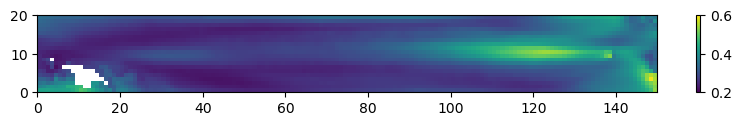

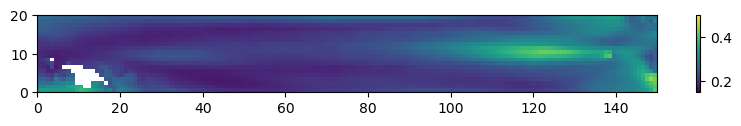

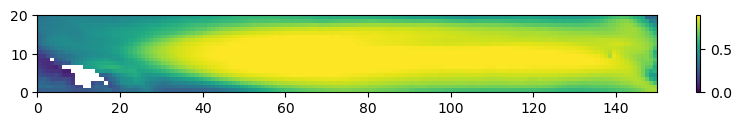

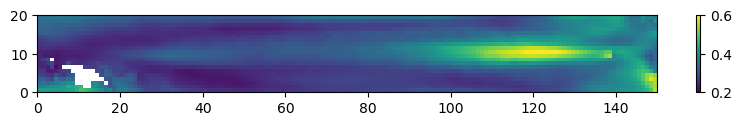

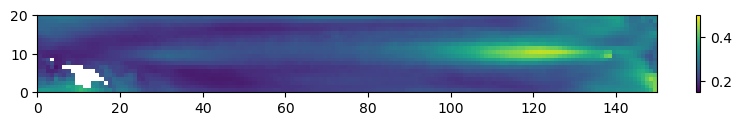

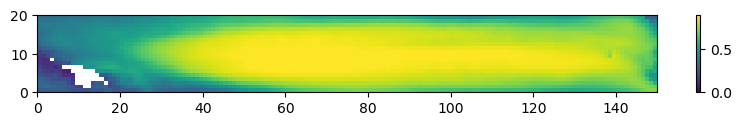

In [63]:
plt.figure(figsize=(10,1)); cb=plt.pcolormesh(sst_train_rmse_map, vmin=0.2, vmax=0.6); plt.colorbar(cb); plt.show()
plt.figure(figsize=(10,1)); cb=plt.pcolormesh(sst_train_mae_map, vmin=0.15, vmax=0.5); plt.colorbar(cb); plt.show()
plt.figure(figsize=(10,1)); cb=plt.pcolormesh(sst_train_r2_map, vmin=0, vmax=0.9); plt.colorbar(cb); plt.show()
plt.figure(figsize=(10,1)); cb=plt.pcolormesh(sst_test_rmse_map, vmin=0.2, vmax=0.6); plt.colorbar(cb); plt.show()
plt.figure(figsize=(10,1)); cb=plt.pcolormesh(sst_test_mae_map, vmin=0.15, vmax=0.5); plt.colorbar(cb); plt.show()
plt.figure(figsize=(10,1)); cb=plt.pcolormesh(sst_test_r2_map, vmin=0, vmax=0.9); plt.colorbar(cb); plt.show()

In [64]:
# ohc spatial metrics
# time aggregated

ohc_train_rmse_map = rmse_per_cell(
    ohc_train_input_reconstructed, ohc_train_output_reconstructed, axis=0
)
ohc_test_rmse_map = rmse_per_cell(
    ohc_test_input_reconstructed, ohc_test_output_reconstructed, axis=0
)
ohc_train_mae_map = mae_per_cell(
    ohc_train_input_reconstructed, ohc_train_output_reconstructed, axis=0
)
ohc_test_mae_map = mae_per_cell(
    ohc_test_input_reconstructed, ohc_test_output_reconstructed, axis=0
)
ohc_train_r2_map = r2_per_cell(
    ohc_train_input_reconstructed, ohc_train_output_reconstructed, axis=0
)
ohc_test_r2_map = r2_per_cell(
    ohc_test_input_reconstructed, ohc_test_output_reconstructed, axis=0
)

/glade/derecho/scratch/ewisinski/tmp/ipykernel_16984/722080907.py:7: RuntimeWarning: Mean of empty slice
  return np.nanmean(sq, axis=axis)
/glade/derecho/scratch/ewisinski/tmp/ipykernel_16984/722080907.py:10: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.abs(y_true - y_pred), axis=axis)
/glade/derecho/scratch/ewisinski/tmp/ipykernel_16984/722080907.py:35: RuntimeWarning: Mean of empty slice
  y_mean = np.nanmean(yt, axis=axis, keepdims=True)


In [65]:
# olr spatial metrics
# time aggregated

olr_train_rmse_map = rmse_per_cell(
    olr_train_input_reconstructed, olr_train_output_reconstructed, axis=0
)
olr_test_rmse_map = rmse_per_cell(
    olr_test_input_reconstructed, olr_test_output_reconstructed, axis=0
)
olr_train_mae_map = mae_per_cell(
    olr_train_input_reconstructed, olr_train_output_reconstructed, axis=0
)
olr_test_mae_map = mae_per_cell(
    olr_test_input_reconstructed, olr_test_output_reconstructed, axis=0
)
olr_train_r2_map = r2_per_cell(
    olr_train_input_reconstructed, olr_train_output_reconstructed, axis=0
)
olr_test_r2_map = r2_per_cell(
    olr_test_input_reconstructed, olr_test_output_reconstructed, axis=0
)

## spatial bootstrapping

Note that the code below uses a less traditional method of bootstrapping, where instead of using a resampled index list, we use a resampled count vector for memory and speed considerations.

In [66]:
def _prep_flat(y_true, y_pred):
    """
    Prepare inputs for fast per-cell bootstrap computations.

    Assumes inputs are shaped (n_samples, ...grid...) with samples on axis 0.
    Flattens grid dims into one dimension of length m.

    Returns
    -------
    yt, yp : np.ndarray, shape (n_samples, m)
        Flattened y_true and y_pred as float64.
    n : int
        Number of samples.
    grid_shape : tuple[int, ...]
        Original grid shape.
    m : int
        Number of grid cells.
    """
    if y_true.shape != y_pred.shape:
        raise ValueError("Shapes must match.")
    if y_true.ndim < 2:
        raise ValueError("Expected shape (n_samples, ...grid...). Got 1D input.")

    n = y_true.shape[0]
    grid_shape = y_true.shape[1:]
    m = int(np.prod(grid_shape))

    yt = np.asarray(y_true, dtype=np.float64).reshape(n, m)
    yp = np.asarray(y_pred, dtype=np.float64).reshape(n, m)
    return yt, yp, n, grid_shape, m

In [67]:
def _percentile_ci(boot, ci=0.95):
    """
    Compute two-tailed percentile CI (NaN-aware) along axis=0.

    Parameters
    ----------
    boot : np.ndarray, shape (n_boot, ...)
        Bootstrap replicates.
    ci : float
        Confidence level, e.g. 0.95.

    Returns
    -------
    lo, hi : np.ndarray
        Lower/upper bounds of the percentile CI.
    """
    alpha = (1.0 - ci) / 2.0
    lo = np.nanpercentile(boot, 100.0 * alpha, axis=0)
    hi = np.nanpercentile(boot, 100.0 * (1.0 - alpha), axis=0)
    return lo, hi

In [68]:
def _draw_bootstrap_weights(n, rng, n_resample=None, block_size=1, circular=True):
    """
    Draw bootstrap weights w (counts per original sample) for one replicate.

    This returns a vector w of length n where w[i] is the number of times sample i
    appears in the bootstrap resample, and sum(w) == n_resample.

    Parameters
    ----------
    n : int
        Number of available samples in the original data.
    rng : np.random.Generator
        RNG.
    n_resample : int | None
        Number of resampled positions in each bootstrap replicate.
        - If None, defaults to n (standard bootstrap replicate length).
        - Must be >= 1.
    block_size : int
        Block length; 1 for IID bootstrap; >=2 for moving block bootstrap.
    circular : bool
        If True, blocks may wrap around the end (indices modulo n).

    Returns
    -------
    w : np.ndarray, shape (n,), dtype int64
        Counts per sample in the resample (sum(w) == n_resample).
    """
    if n_resample is None:
        n_resample = n
    n_resample = int(n_resample)
    if n_resample < 1:
        raise ValueError("n_resample must be >= 1")

    block_size = int(block_size)
    if block_size <= 1:
        # IID bootstrap counts: sum(w) = n_resample
        p = np.full(n, 1.0 / n, dtype=np.float64)
        return rng.multinomial(n_resample, p)

    if block_size > n:
        raise ValueError(f"block_size={block_size} cannot exceed n_samples={n}.")

    # Number of blocks needed to reach at least n_resample positions
    k = (n_resample + block_size - 1) // block_size  # ceil(n_resample / block_size)

    if circular:
        starts = rng.integers(0, n, size=k, endpoint=False)
    else:
        max_start = n - block_size
        if max_start < 0:
            raise ValueError("Non-circular block bootstrap requires block_size <= n.")
        starts = rng.integers(0, max_start + 1, size=k, endpoint=False)

    w = np.zeros(n, dtype=np.int64)
    remaining = n_resample

    for s in starts:
        L = block_size if remaining >= block_size else remaining
        if circular:
            idx = (s + np.arange(L)) % n
        else:
            idx = s + np.arange(L)
        np.add.at(w, idx, 1)
        remaining -= L
        if remaining <= 0:
            break

    return w

In [69]:
def _one_sided_bound(boot, alpha=0.05, tail="upper"):
    """
    Return a one-sided percentile bound from bootstrap replicates (NaN-aware).

    Parameters
    ----------
    boot : np.ndarray, shape (n_boot, ...)
        Bootstrap replicates of the statistic.
    alpha : float
        Significance level for a one-sided test. Commonly 0.05.
    tail : {"upper", "lower"}
        - "upper": returns q_(1-alpha) (use for metrics where larger = worse, e.g., RMSE/MAE)
        - "lower": returns q_(alpha) (use for metrics where smaller = worse, e.g., R^2)

    Returns
    -------
    bound : np.ndarray, shape boot.shape[1:]
        One-sided percentile bound.
    """
    alpha = float(alpha)
    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be between 0 and 1")

    tail = str(tail).lower()
    if tail == "upper":
        q = 100.0 * (1.0 - alpha)
    elif tail == "lower":
        q = 100.0 * alpha
    else:
        raise ValueError("tail must be 'upper' or 'lower'")

    return np.nanpercentile(boot, q, axis=0)

In [70]:
def bootstrap_ci_mae_bounds(
    y_true, y_pred,
    n_boot=1000, ci=0.95, random_state=None,
    store_dtype=np.float32,
    block_size=1, circular=True,
    n_resample=None,
):
    """
    Return (lo, hi) percentile bootstrap CI bounds for per-cell MAE.

    New parameter
    -------------
    n_resample : int | None
        Number of resampled positions per replicate (m-out-of-n / shorter bootstrap).
        If None, defaults to n_samples (standard).
    """
    yt, yp, n, grid_shape, m = _prep_flat(y_true, y_pred)

    valid = np.isfinite(yt) & np.isfinite(yp)
    v = valid.astype(np.float64)

    absdiff0 = np.abs(np.where(valid, yt - yp, 0.0))

    boot = np.empty((n_boot, m), dtype=store_dtype)
    rng = np.random.default_rng(random_state)

    for b in range(n_boot):
        w = _draw_bootstrap_weights(
            n, rng, n_resample=n_resample, block_size=block_size, circular=circular
        )
        denom = np.einsum("i,ij->j", w, v)
        num = np.einsum("i,ij->j", w, absdiff0)
        with np.errstate(invalid="ignore", divide="ignore"):
            mae_b = num / denom
        mae_b = np.where(denom == 0, np.nan, mae_b)
        boot[b] = mae_b.astype(store_dtype, copy=False)

    lo, hi = _percentile_ci(boot, ci=ci)
    return lo.reshape(grid_shape), hi.reshape(grid_shape)

In [71]:
def bootstrap_mae_upper_bound(
    y_true, y_pred,
    n_boot=1000, alpha=0.05, random_state=None,
    store_dtype=np.float32,
    block_size=1, circular=True,
    n_resample=None,
):
    """
    Bootstrap one-sided (upper) bound for per-cell MAE from training data.

    A test MAE value > bound is flagged as "significantly worse" at one-sided level alpha.
    """
    yt, yp, n, grid_shape, m = _prep_flat(y_true, y_pred)

    valid = np.isfinite(yt) & np.isfinite(yp)
    v = valid.astype(np.float64)

    absdiff0 = np.abs(np.where(valid, yt - yp, 0.0))

    boot = np.empty((n_boot, m), dtype=store_dtype)
    rng = np.random.default_rng(random_state)

    for b in range(n_boot):
        w = _draw_bootstrap_weights(
            n, rng, n_resample=n_resample, block_size=block_size, circular=circular
        )
        denom = np.einsum("i,ij->j", w, v)
        num = np.einsum("i,ij->j", w, absdiff0)

        with np.errstate(invalid="ignore", divide="ignore"):
            mae_b = num / denom
        mae_b = np.where(denom == 0, np.nan, mae_b)
        boot[b] = mae_b.astype(store_dtype, copy=False)

    bound = _one_sided_bound(boot, alpha=alpha, tail="upper")
    return bound.reshape(grid_shape)

In [72]:
def bootstrap_ci_rmse_bounds(
    y_true, y_pred,
    n_boot=1000, ci=0.95, random_state=None,
    store_dtype=np.float32,
    block_size=1, circular=True,
    n_resample=None,
):
    """
    Return (lo, hi) percentile bootstrap CI bounds for per-cell RMSE.

    New parameter
    -------------
    n_resample : int | None
        Number of resampled positions per replicate.
        If None, defaults to n_samples.
    """
    yt, yp, n, grid_shape, m = _prep_flat(y_true, y_pred)

    valid = np.isfinite(yt) & np.isfinite(yp)
    v = valid.astype(np.float64)

    diff0 = np.where(valid, yt - yp, 0.0)
    sqdiff0 = diff0 * diff0

    boot = np.empty((n_boot, m), dtype=store_dtype)
    rng = np.random.default_rng(random_state)

    for b in range(n_boot):
        w = _draw_bootstrap_weights(
            n, rng, n_resample=n_resample, block_size=block_size, circular=circular
        )
        denom = np.einsum("i,ij->j", w, v)
        num = np.einsum("i,ij->j", w, sqdiff0)
        with np.errstate(invalid="ignore", divide="ignore"):
            mse_b = num / denom
        mse_b = np.where(denom == 0, np.nan, mse_b)
        rmse_b = np.sqrt(mse_b)
        boot[b] = rmse_b.astype(store_dtype, copy=False)

    lo, hi = _percentile_ci(boot, ci=ci)
    return lo.reshape(grid_shape), hi.reshape(grid_shape)

In [73]:
def bootstrap_rmse_upper_bound(
    y_true, y_pred,
    n_boot=1000, alpha=0.05, random_state=None,
    store_dtype=np.float32,
    block_size=1, circular=True,
    n_resample=None,
):
    """
    Bootstrap one-sided (upper) bound for per-cell RMSE from training data.

    Interpretation
    --------------
    This returns the (1-alpha) percentile of the bootstrap RMSE distribution per cell.
    A test RMSE value > bound is flagged as "significantly worse" at one-sided level alpha.

    Notes
    -----
    - Paired validity: uses only points where both y_true and y_pred are finite.
    - Block bootstrap supported via block_size>=2 (recommended for monthly time series).
    - n_resample sets the resample length; default uses full length n.
    """
    yt, yp, n, grid_shape, m = _prep_flat(y_true, y_pred)

    valid = np.isfinite(yt) & np.isfinite(yp)
    v = valid.astype(np.float64)

    diff0 = np.where(valid, yt - yp, 0.0)
    sqdiff0 = diff0 * diff0

    boot = np.empty((n_boot, m), dtype=store_dtype)
    rng = np.random.default_rng(random_state)

    for b in range(n_boot):
        w = _draw_bootstrap_weights(
            n, rng, n_resample=n_resample, block_size=block_size, circular=circular
        )
        denom = np.einsum("i,ij->j", w, v)
        num = np.einsum("i,ij->j", w, sqdiff0)

        with np.errstate(invalid="ignore", divide="ignore"):
            mse_b = num / denom
        mse_b = np.where(denom == 0, np.nan, mse_b)

        boot[b] = np.sqrt(mse_b).astype(store_dtype, copy=False)

    bound = _one_sided_bound(boot, alpha=alpha, tail="upper")
    return bound.reshape(grid_shape)

In [74]:
def bootstrap_ci_r2_bounds(
    y_true, y_pred,
    n_boot=1000, ci=0.95, random_state=None,
    min_count=2, store_dtype=np.float32,
    block_size=1, circular=True,
    n_resample=None,
):
    """
    Return (lo, hi) percentile bootstrap CI bounds for per-cell R^2.

    New parameter
    -------------
    n_resample : int | None
        Number of resampled positions per replicate.
        If None, defaults to n_samples.

    Important
    ---------
    min_count is applied to the *weighted* paired-valid count in each replicate:
      denom = sum_i w_i * valid_i
    """
    yt, yp, n, grid_shape, m = _prep_flat(y_true, y_pred)

    valid = np.isfinite(yt) & np.isfinite(yp)
    v = valid.astype(np.float64)

    yt0 = np.where(valid, yt, 0.0)
    diff0 = np.where(valid, yt - yp, 0.0)
    sqdiff0 = diff0 * diff0
    yt2_0 = yt0 * yt0

    boot = np.empty((n_boot, m), dtype=store_dtype)
    rng = np.random.default_rng(random_state)

    for b in range(n_boot):
        w = _draw_bootstrap_weights(
            n, rng, n_resample=n_resample, block_size=block_size, circular=circular
        )

        denom = np.einsum("i,ij->j", w, v)
        ysum  = np.einsum("i,ij->j", w, yt0)
        y2sum = np.einsum("i,ij->j", w, yt2_0)
        ss_res = np.einsum("i,ij->j", w, sqdiff0)

        with np.errstate(invalid="ignore", divide="ignore"):
            ymean = ysum / denom

        ss_tot = y2sum - 2.0 * ymean * ysum + (ymean * ymean) * denom

        with np.errstate(invalid="ignore", divide="ignore"):
            r2_b = 1.0 - ss_res / ss_tot

        r2_b = np.where((ss_tot == 0) | (denom < min_count), np.nan, r2_b)
        boot[b] = r2_b.astype(store_dtype, copy=False)

    lo, hi = _percentile_ci(boot, ci=ci)
    return lo.reshape(grid_shape), hi.reshape(grid_shape)

In [75]:
def bootstrap_r2_lower_bound(
    y_true, y_pred,
    n_boot=1000, alpha=0.05, random_state=None,
    min_count=2, store_dtype=np.float32,
    block_size=1, circular=True,
    n_resample=None,
):
    """
    Bootstrap one-sided (lower) bound for per-cell R^2 from training data.

    Interpretation
    --------------
    This returns the alpha percentile of the bootstrap R^2 distribution per cell.
    A test R^2 value < bound is flagged as "significantly worse" at one-sided level alpha.

    NaN rules match your prior r2 logic:
    - paired-finite only
    - undefined if SS_tot==0 or valid-count < min_count (in that replicate)
    """
    yt, yp, n, grid_shape, m = _prep_flat(y_true, y_pred)

    valid = np.isfinite(yt) & np.isfinite(yp)
    v = valid.astype(np.float64)

    yt0 = np.where(valid, yt, 0.0)
    diff0 = np.where(valid, yt - yp, 0.0)
    sqdiff0 = diff0 * diff0
    yt2_0 = yt0 * yt0

    boot = np.empty((n_boot, m), dtype=store_dtype)
    rng = np.random.default_rng(random_state)

    for b in range(n_boot):
        w = _draw_bootstrap_weights(
            n, rng, n_resample=n_resample, block_size=block_size, circular=circular
        )

        denom = np.einsum("i,ij->j", w, v)
        ysum  = np.einsum("i,ij->j", w, yt0)
        y2sum = np.einsum("i,ij->j", w, yt2_0)
        ss_res = np.einsum("i,ij->j", w, sqdiff0)

        with np.errstate(invalid="ignore", divide="ignore"):
            ymean = ysum / denom

        ss_tot = y2sum - 2.0 * ymean * ysum + (ymean * ymean) * denom

        with np.errstate(invalid="ignore", divide="ignore"):
            r2_b = 1.0 - ss_res / ss_tot

        r2_b = np.where((ss_tot == 0) | (denom < min_count), np.nan, r2_b)
        boot[b] = r2_b.astype(store_dtype, copy=False)

    bound = _one_sided_bound(boot, alpha=alpha, tail="lower")
    return bound.reshape(grid_shape)

In [76]:
sst_rmse_upper = bootstrap_rmse_upper_bound(
    sst_train_input_reconstructed, sst_train_output_reconstructed,
    n_boot=1000, alpha=0.05, random_state=0,
    block_size=1, circular=False,
    # block_size=36, circular=True,
    n_resample=1200,   # or 4800; your choice
)

sst_mae_upper = bootstrap_mae_upper_bound(
    sst_train_input_reconstructed, sst_train_output_reconstructed,
    n_boot=1000, alpha=0.05, random_state=0,
    block_size=1, circular=False,
    # block_size=36, circular=True,
    n_resample=1200,   # or 4800; your choice
)

sst_r2_lower = bootstrap_r2_lower_bound(
    sst_train_input_reconstructed, sst_train_output_reconstructed,
    n_boot=1000, alpha=0.05, random_state=0,
    block_size=1, circular=False, min_count=2,
    # block_size=36, circular=True, min_count=2,
    n_resample=1200
)

/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [77]:
ohc_rmse_upper = bootstrap_rmse_upper_bound(
    ohc_train_input_reconstructed, ohc_train_output_reconstructed,
    n_boot=1000, alpha=0.05, random_state=0,
    block_size=1, circular=False,
    # block_size=36, circular=True,
    n_resample=1200,   # or 4800; your choice
)

ohc_mae_upper = bootstrap_mae_upper_bound(
    ohc_train_input_reconstructed, ohc_train_output_reconstructed,
    n_boot=1000, alpha=0.05, random_state=0,
    block_size=1, circular=False,
    # block_size=36, circular=True,
    n_resample=1200,   # or 4800; your choice
)

ohc_r2_lower = bootstrap_r2_lower_bound(
    ohc_train_input_reconstructed, ohc_train_output_reconstructed,
    n_boot=1000, alpha=0.05, random_state=0,
    block_size=1, circular=False, min_count=2,
    # block_size=36, circular=True, min_count=2,
    n_resample=1200
)

In [78]:
olr_rmse_upper = bootstrap_rmse_upper_bound(
    olr_train_input_reconstructed, olr_train_output_reconstructed,
    n_boot=1000, alpha=0.05, random_state=0,
    block_size=1, circular=False,
    # block_size=36, circular=True,
    n_resample=1200,   # or 4800; your choice
)

olr_mae_upper = bootstrap_mae_upper_bound(
    olr_train_input_reconstructed, olr_train_output_reconstructed,
    n_boot=1000, alpha=0.05, random_state=0,
    block_size=1, circular=False,
    # block_size=36, circular=True,
    n_resample=1200,   # or 4800; your choice
)

olr_r2_lower = bootstrap_r2_lower_bound(
    olr_train_input_reconstructed, olr_train_output_reconstructed,
    n_boot=1000, alpha=0.05, random_state=0,
    block_size=1, circular=False, min_count=2,
    # block_size=36, circular=True, min_count=2,
    n_resample=1200
)

## plotting

In [79]:
# lat lon for plots
ocn_lat = xr.open_dataset(
    '/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/preprocessing/ocean_formaria.nc'
).lat.values
ocn_lon = xr.open_dataset(
    '/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/preprocessing/ocean_formaria.nc'
).lon.values
ocn_lon_label = ((ocn_lon + 180) % 360) - 180

atm_lat = xr.open_dataset(
    '/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/preprocessing/atmosphere_formaria.nc'
).lat.values
atm_lon = xr.open_dataset(
    '/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/preprocessing/atmosphere_formaria.nc'
).lon.values
atm_lon_label = ((atm_lon + 180) % 360) - 180

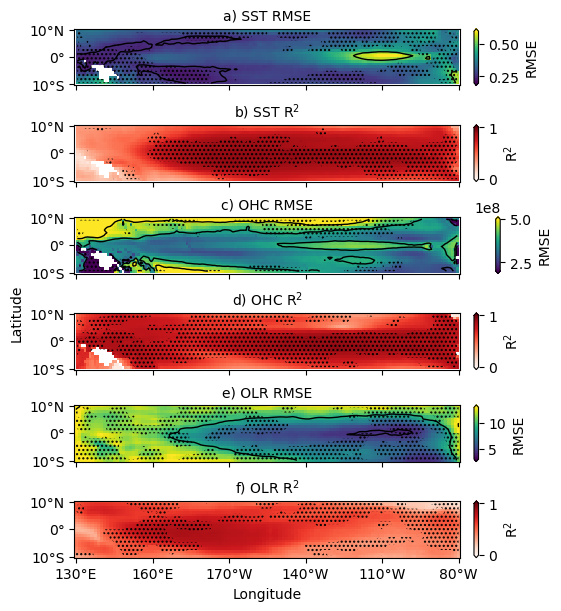

In [81]:
fig, axs = plt.subplots(
    nrows=6, ncols=1,
    figsize=(5.5, 6),
    constrained_layout=True,
    sharex=True, sharey=True
)

def plot_panel(ax, lon, lat, data, vmin=None, vmax=None, 
               title="", mask=None, clabel=None, extend=None, cmap=None):
    
    m = ax.pcolormesh(lon, lat, data, vmin=vmin, vmax=vmax, shading="auto", cmap=cmap)
    
    fig.colorbar(m, ax=ax, shrink=1, pad=-0.01, label=clabel, extend=extend, aspect=12.5)
    
    if mask is not None:
        
        if mask.shape != data.shape:
            raise ValueError(f"Mask shape {mask.shape} != data shape {data.shape} for panel '{title}'")
            
        ax.contourf(
            lon, lat, mask.astype(int),
            levels=[0.5, 1.5],
            colors="none",
            hatches=["...."]
        )
        
    ax.set_title(title, fontsize=10)

def get_err_mask(map, upper):
    valid = np.isfinite(map) & np.isfinite(upper)
    worse_ = valid & (map > upper)
    not_worse = valid & ~worse_
    return not_worse

def get_r2_mask(map, lower):
    valid = np.isfinite(map) & np.isfinite(lower)
    worse_ = valid & (map < lower)
    not_worse = valid & ~worse_
    return not_worse


############### SST RMSE/MAE

plot_panel(
    axs[0], 
    ocn_lon, ocn_lat, sst_test_rmse_map, 
    vmin=0.2, vmax=0.6, title="a) SST RMSE", 
    mask=get_err_mask(
        sst_test_rmse_map, 
        sst_rmse_upper
    ),
    clabel=r"RMSE", extend='both'
)
axs[0].contour(
    ocn_lon, ocn_lat, sst_test_mae_map, 
    levels=[0.2, 0.4, 0.6], colors='k', linewidths=1.
)

############### SST R2

plot_panel(
    axs[1], 
    ocn_lon, ocn_lat, sst_test_r2_map, 
    vmin=0, vmax=1, title=r"b) SST R$^2$", 
    mask=get_err_mask(
        sst_test_r2_map, 
        sst_r2_lower
    ),
    clabel=r"R$^2$", extend='both', cmap='Reds'
)

############### OHC RMSE/MAE

plot_panel(
    axs[2], 
    ocn_lon, ocn_lat, ohc_test_rmse_map, 
    vmin=2e8, vmax=5e8, title="c) OHC RMSE", 
    mask=get_err_mask(
        ohc_test_rmse_map, 
        ohc_rmse_upper
    ),
    clabel=r"RMSE", extend='both'
)
axs[2].contour(
    ocn_lon, ocn_lat, ohc_test_mae_map, 
    levels=[2e8, 3e8, 4e8], colors='k', linewidths=1.
)

############### OHC R2

plot_panel(
    axs[3], 
    ocn_lon, ocn_lat, ohc_test_r2_map, 
    vmin=0, vmax=1, title=f"d) OHC R$^2$", 
    mask=get_err_mask(
        ohc_test_r2_map, 
        ohc_r2_lower
    ),
    clabel=r"R$^2$", extend='both', cmap='Reds'
)

############### OLR RMSE/MAE

plot_panel(
    axs[4], 
    atm_lon, atm_lat, olr_test_rmse_map, 
    vmin=3, vmax=13, title="e) OLR RMSE", 
    mask=get_err_mask(
        olr_test_rmse_map, 
        olr_rmse_upper
    ),
    clabel=r"RMSE", extend='both'
)
axs[4].contour(
    atm_lon, atm_lat, olr_test_mae_map, 
    levels=[3, 7, 11], colors='k', linewidths=1.
)

############### OLR R2


plot_panel(
    axs[5], 
    atm_lon, atm_lat, olr_test_r2_map, 
    vmin=0, vmax=1., title=f"f) OLR R$^2$", 
    mask=get_err_mask(
        olr_test_r2_map, 
        olr_r2_lower
    ),
    clabel=r"R$^2$", extend='both', cmap='Reds'
)

# Example: label only a few longitudes
# Choose a subset of longitudes you want as ticks
tick_lons = np.array([130, 160, 190, 220, 250, 280])

# Convert to E/W labels
tick_labels = []
for lon in tick_lons:
    if lon <= 180:
        tick_labels.append(f"{int(lon)}°E")
    else:
        tick_labels.append(f"{360 - int(lon)}°W")

# Set the ticks on the axis
axs[5].set_xticks(tick_lons)
axs[5].set_xticklabels(tick_labels)
axs[5].set_xlabel("Longitude")

lat_ticks = np.arange(-10, 11, 10)  # e.g., -10, -5, 0, 5, 10

lat_labels = []
for lat in lat_ticks:
    if lat < 0:
        lat_labels.append(f"{abs(lat)}°S")
    elif lat > 0:
        lat_labels.append(f"{lat}°N")
    else:
        lat_labels.append("0°")

axs[3].set_yticks(lat_ticks)
axs[3].set_yticklabels(lat_labels)
axs[3].set_ylabel("Latitude", y=1.)

plt.savefig('bvae_test_metrics_0212.pdf', transparent=True, bbox_inches='tight') # note saving as pdf is important for publication
plt.show()